<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro14YOLO/yolo6dataframe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 이미지 탐지 결과를 DataFrame에 저장 후 CSV로 저장한 후 이를 읽어 -> 요약 통계 처리
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.3 MB/s eta 0:00:00


In [9]:
import os
import pandas as pd
from ultralytics import YOLO

model = YOLO('yolo11n.pt')
img_dir = 'images'
img_paths = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith((".jpg",".jpeg",".png"))]
print('img_paths :', img_paths)

records = []

for path in img_paths:
  results = model(path, conf=0.25, verbose=False)[0]  # 단일 이미지 추론
  boxes = results.boxes
  names = results.names
  # print(names)

  if len(boxes) == 0:
    records.append({
        'image':os.path.basename(path),
        'object_count':0,
        'classes':'',
        'avg_confidence':0.0
    })
    continue

  # cpu() : pytorch 텐서로 반환된 값을 cpu 메모리로 옮겨 numpy 배열로 변환
  cls_id = boxes.cls.cpu().numpy().astype(int)  # 탐지된 객체들의 클래스 id(정수 라벨 번호)
  print('cls_id :', cls_id)   # [0 0 3 0 0 2] 이미지 6개 감지 ...
  confs = boxes.conf.cpu().numpy()
  print('confs :', confs)   # [    0.89472     0.88528     0.84669     0.69414     0.28265     0.25905]

  classes = [names[i] for i in cls_id]
  print('classes :', classes)   # ['person', 'person', 'motorcycle', 'person', 'person', 'car']
  avg_conf = float(confs.mean())

  records.append({
        'image':os.path.basename(path),
        'object_count':len(cls_id),
        'classes':','.join(sorted(set(classes))),
        'avg_confidence':round(avg_conf, 3)
    })

img_paths : ['images/image3.png', 'images/image1.jpg', 'images/image2.jpeg']
cls_id : [0 0 3 0 0 2]
confs : [    0.89472     0.88528     0.84669     0.69414     0.28265     0.25905]
classes : ['person', 'person', 'motorcycle', 'person', 'person', 'car']
cls_id : [0 0]
confs : [    0.81587     0.46298]
classes : ['person', 'person']
cls_id : [ 0  0 26  0]
confs : [    0.82473     0.72216     0.43466     0.30244]
classes : ['person', 'person', 'handbag', 'person']


In [14]:
# records로 DataFrame에 저장
df = pd.DataFrame(records)
print(df)
df.to_csv('yolo6report.csv', index=False, encoding='utf-8-sig')
print('csv로 저장 성공')

         image  object_count                classes  avg_confidence
0   image3.png             6  car,motorcycle,person           0.644
1   image1.jpg             2                 person           0.639
2  image2.jpeg             4         handbag,person           0.571
csv로 저장 성공


         image  object_count                classes  avg_confidence
0   image3.png             6  car,motorcycle,person           0.644
1   image1.jpg             2                 person           0.639
2  image2.jpeg             4         handbag,person           0.571
총 이미지 수 : 3
총 탐지 개수 : 12
전체 confidence 평균 :  0.618
클래스 별 등장 이미지 수 :
car : 1
motorcycle : 1
person : 3
handbag : 1
       object_count  avg_confidence
count           3.0         3.00000
mean            4.0         0.61800
std             2.0         0.04078
min             2.0         0.57100
25%             3.0         0.60500
50%             4.0         0.63900
75%             5.0         0.64150
max             6.0         0.64400
가장 많이 감지된 객체는 image                        image3.png
object_count                          6
classes           car,motorcycle,person
avg_confidence                    0.644
Name: 0, dtype: object


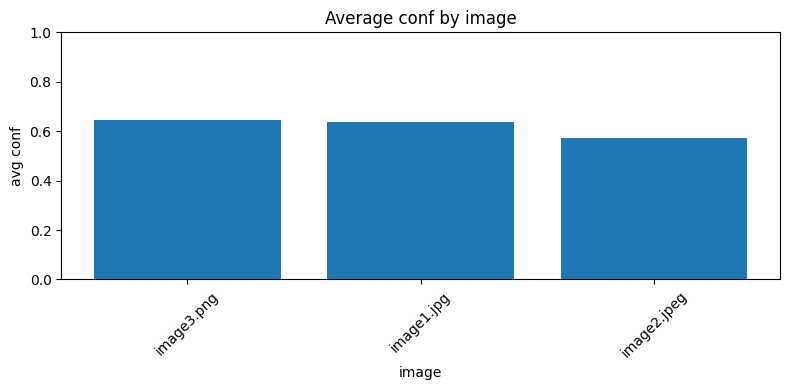

In [22]:
# csv 로딩
mydf = pd.read_csv('yolo6report.csv')
print(mydf)

num_images = len(mydf)
total_objects = mydf['object_count'].sum()   # 탐지 객체 총 갯수

# 전체 confidence 평균
overall_avg_conf = mydf.loc[mydf['avg_confidence'] > 0, 'avg_confidence'].mean() if total_objects > 0 else 0.0

print(f'총 이미지 수 : {num_images}')
print('총 탐지 개수 :', total_objects)
print('전체 confidence 평균 : ', overall_avg_conf)

class_counts = {}
for cls_str in mydf['classes']:
  if cls_str:
    for c in cls_str.split(','):
      class_counts[c] = class_counts.get(c, 0) + 1  # 나눠진 리스트를 하나씩 반복

print('클래스 별 등장 이미지 수 :')
for k, v in class_counts.items():
  print(f'{k} : {v}')

print(mydf[['object_count', 'avg_confidence']].describe())

max_row = mydf.loc[mydf['object_count'].idxmax()]
print('가장 많이 감지된 객체는', max_row)

import matplotlib.pyplot as plt

# 평균 신뢰도 막대 그래프
plt.figure(figsize=(8, 4))
plt.bar(mydf['image'], mydf['avg_confidence'])
plt.title('Average conf by image')
plt.xlabel('image')
plt.ylabel('avg conf')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()